# TC 5033
## Deep Learning
## Fully Connected Deep Neural Networks

#### Activity 1b: Implementing a Fully Connected Network for Kaggle ASL Dataset

- Objective

The aim of this part of the activity is to apply your understanding of Fully Connected Networks by implementing a multilayer network for the [Kaggle ASL (American Sign Language) dataset](https://www.kaggle.com/datasets/grassknoted/asl-alphabet). While you have been provided with a complete solution for a Fully Connected Network using Numpy for the MNIST dataset, you are encouraged to try to come up with the solution.

- Instructions

    This activity requires submission in teams of 3 or 4 members. Submissions from smaller or larger teams will not be accepted unless prior approval has been granted (only due to exceptional circumstances). While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Load and Preprocess Data: You are provided a starter code to load the data. Be sure to understand the code.

    Review MNIST Notebook (Optional): Before diving into this activity, you have the option to revisit the MNIST example to refresh your understanding of how to build a Fully Connected Network using Numpy.

    Start Fresh: Although you can refer to the MNIST solution at any point, try to implement the network for the ASL dataset on your own. This will reinforce your learning and understanding of the architecture and mathematics involved.

    Implement Forward and Backward Pass: Write the code to perform the forward and backward passes, keeping in mind the specific challenges and characteristics of the ASL dataset.
    
     Design the Network: Create the architecture of the Fully Connected Network tailored for the ASL dataset. Choose the number of hidden layers, neurons, and hyperparameters judiciously.

    Train the Model: Execute the training loop, ensuring to track performance metrics such as loss and accuracy.

    Analyze and Document: Use Markdown cells to document in detail the choices you made in terms of architecture and hyperparameters, you may use figures, equations, etc to aid in your explanations. Include any metrics that help justify these choices and discuss the model's performance.  

- Evaluation Criteria

    - Code Readability and Comments
    - Appropriateness of chosen architecture and hyperparameters for the ASL dataset
    - Performance of the model on the ASL dataset (at least 70% acc)
    - Quality of Markdown documentation

- Submission

Submit this Jupyter Notebook in canvas with your complete solution, ensuring your code is well-commented and includes Markdown cells that explain your design choices, results, and any challenges you encountered.


In [16]:
import numpy as np
import string
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import os

%load_ext autoreload
%autoreload 2
#################################
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# DATA_PATH = '/media/pepe/DataUbuntu/Databases/asl_data/'
DATA_PATH = 'C:\\Users\\jfmag\\OneDrive\\Documentos\\Maestría\\Redes Neuronales\\asl_data\\asl_data'
train_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_train.csv'))
valid_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_valid.csv'))

In [18]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


### Importar Images

In [19]:
y_train = np.array(train_df['label'])
y_val = np.array(valid_df['label'])
del train_df['label']
del valid_df['label']
x_train = train_df.values.astype(np.float32)
x_val = valid_df.values.astype(np.float32)

In [20]:
x_val.shape, y_val.shape

((7172, 784), (7172,))

In [21]:
def split_val_test(x, y, pct=0.5, shuffle=True):
    '''
    Create a function that will allow you to split the previously loaded validation set
    into valition and test.
    '''
    #generate an array of indices and shuffle it
    idx=np.arange(x.shape[0])
    if shuffle:
        np.random.shuffle(idx)
        #el random.shuffle guarda el nuevo orden dentro de la misma variable, no es necesario reasignar el resutlado
    #split the indices
    split=int(x.shape[0]*pct)
    #order the dataset according to the shuffle
    x, y=x[idx], y[idx]
    #hacemos el split
    x_val, y_val=x[:split], y[:split]
    x_test, y_test=x[split:], y[split:]
    return x_val, y_val, x_test, y_test


In [22]:
x_val, y_val, x_test, y_test = split_val_test(x_val, y_val)

In [23]:
### The following

alphabet=list(string.ascii_lowercase)
alphabet.remove('j')
alphabet.remove('z')
print(len(alphabet))

24


### Normalise

In [24]:
mu = x_train.mean()
sigma = x_train.std()
x_train = (x_train - mu) / sigma
x_val   = (x_val   - mu) / sigma
x_test  = (x_test  - mu) / sigma

In [25]:
x_train.mean(), x_train.std()

(np.float32(3.6268384e-06), np.float32(0.99999946))

### Graficar muestras

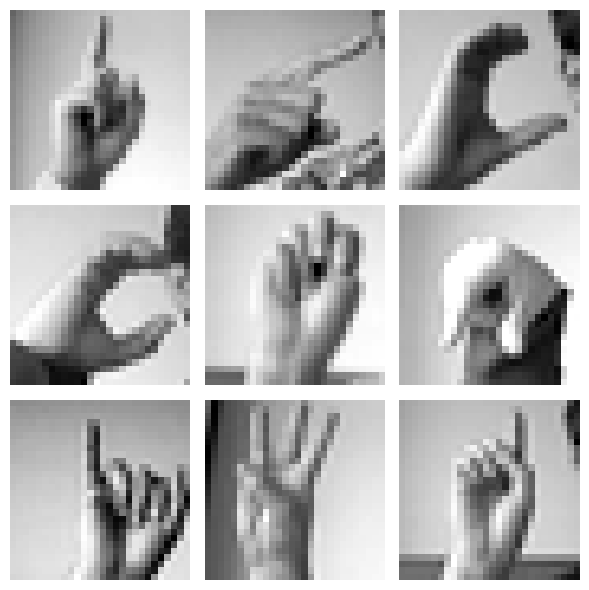

In [30]:
plt.figure(figsize=(6, 6))

#el loop recorre las primeras 9 filas
for i in range(0, 9):
    '''
    como tenemos una una tabla con 784 columnas, 
    cada fila representa una imagen aplastada
    entonces lo que hago es un reshape para darle formato de 28X28
    '''
    img = x_train[i].reshape(28, 28) 
    # Grid 3×3
    plt.subplot(3, 3, i + 1)           
    plt.imshow(img, cmap="gray")#escala de grises   
    plt.axis("off")            #quito los ejes       

plt.tight_layout()
plt.show()

### Ecuaciones para nuestro modelo


$$z^1 = W^1 X + b^1$$

$$a^1 = ReLU(z^1) $$

$$z^2 = W^2 a^1 + b^2$$

$$\hat{y} = \frac{e^{z^{2_k}}}{\sum_j{e^{z_j}}}$$


$$ \mathcal{L}(\hat{y}^{i}, y^{i}) =  - y^{i}  \ln(\hat{y}^{i}) = -\ln(\hat{y}^i)$$


$$ \mathcal{J}(w, b) =  \frac{1}{num\_samples} \sum_{i=1}^{num\_samples}-\ln(\hat{y}^{i})$$

### Funciones adicionales

#### Mini batches

batch(i) = x_train[i:i+batch_size]

y los voy a hacer de 16 imagenes pr batch

batch(k)= x_train[k:k+16]

In [70]:
def get_minibatches(x, y, batch_size=16):
    for i in range(0, len(x), batch_size):
        yield x[i:i+batch_size], y[i:i+batch_size]


TIP de buena práctica:
    range(0, len(x), batch_size) el looop itera en el largo del dataset en bloques del tamañpo del batch size
TIP para no parar una función:
    lo que hace el yield es devolver el minibatch y "pausa" la función, cuando la vuelves a invocar continúa donde se quedó.
    Con return la función para y ya no conitnua, sería como arrancar desde 0 de nuevo por lo que en rango el loop rendría que tener una flag que indicara en qué minibatch se quedó

## Nuestra clase Linear, ReLU y Sequential

###  Clase Linear

La priemra entradason las filas de los minibatches, mientras que enlas posteriores, son lassalidas de las capas anteriores.

The Kaiming initialization method is calculated as a random number with a Gaussian probability distribution (G) with a mean of 0.0 and a standard deviation of sqrt(2/n), where n is the number of inputs to the node.

W → N (0,sqrt(2/n))

The factor of 2 in the variance is specific to the ReLU activation function. For other activation functions, such as sigmoid or hyperbolic tangent, different initialization strategies might be more appropriate.

In [54]:
class l1():
    def __init__(self, output_size, input_size):
        ''''
        np.random.randn genera la matriz con dimensiones (output_size, input_size)
        pero dentro de escalas de valores entre 0,1 y estandarizada
        '''
        self.W= np.random.randn(output_size, input_size) / np.sqrt(input_size/2)
        self.b = np.zeros((output_size, 1))
        self.W_grad = np.zeros((output_size, input_size))
        self.b_grad= np.zeros((output_size, 1))
    #esto es el forward propagation
    #X es la entrada de la capa
    def __call__(self, X):
        self.X= X
        Z = self.W @ X + self.b
        return Z
    def backward(self, dZ):
        self.W_grad = dZ @ self.X.T
        self.b_grad = np.sum(dZ, axis=1, keepdims=True)
        #Gradiente hacia la capa anterior
        dX = self.W.T @ dZ
        return dX
        

In [67]:
class linear:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(out_features, in_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros((out_features, 1))
        self.X = None

    def __call__(self, X):
        # X: (in_features, batch)
        self.X = X
        return self.W @ X + self.b   # (out_features, batch)

    def backward(self, dZ):
        # dZ: (out_features, batch)
        self.dW = dZ @ self.X.T
        self.db = np.sum(dZ, axis=1, keepdims=True)
        return self.W.T @ dZ         # (in_features, batch)

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

Resumen del CALL ( Forward propagation):
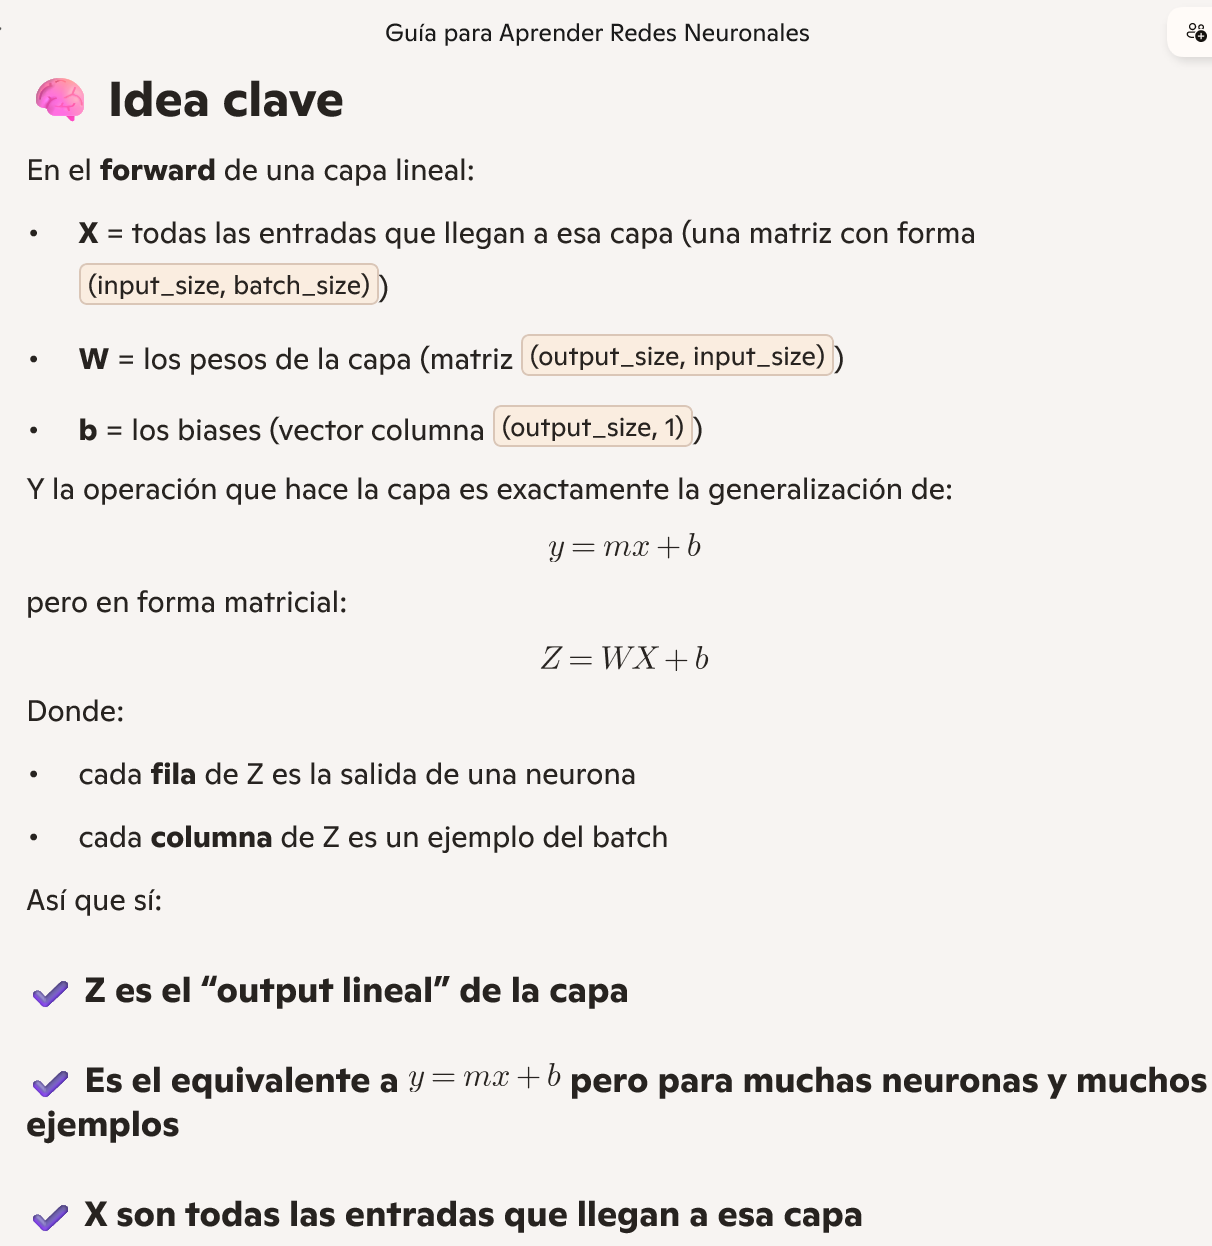


RECUERDA: Y=MX+B es lo mismo:
    M=W=Neuronas
    x= matriz de los inputs por capa
    b=B=matriz de biases que antes conocía como pendiente

![alt text](image.png)

resumen del forward y backward
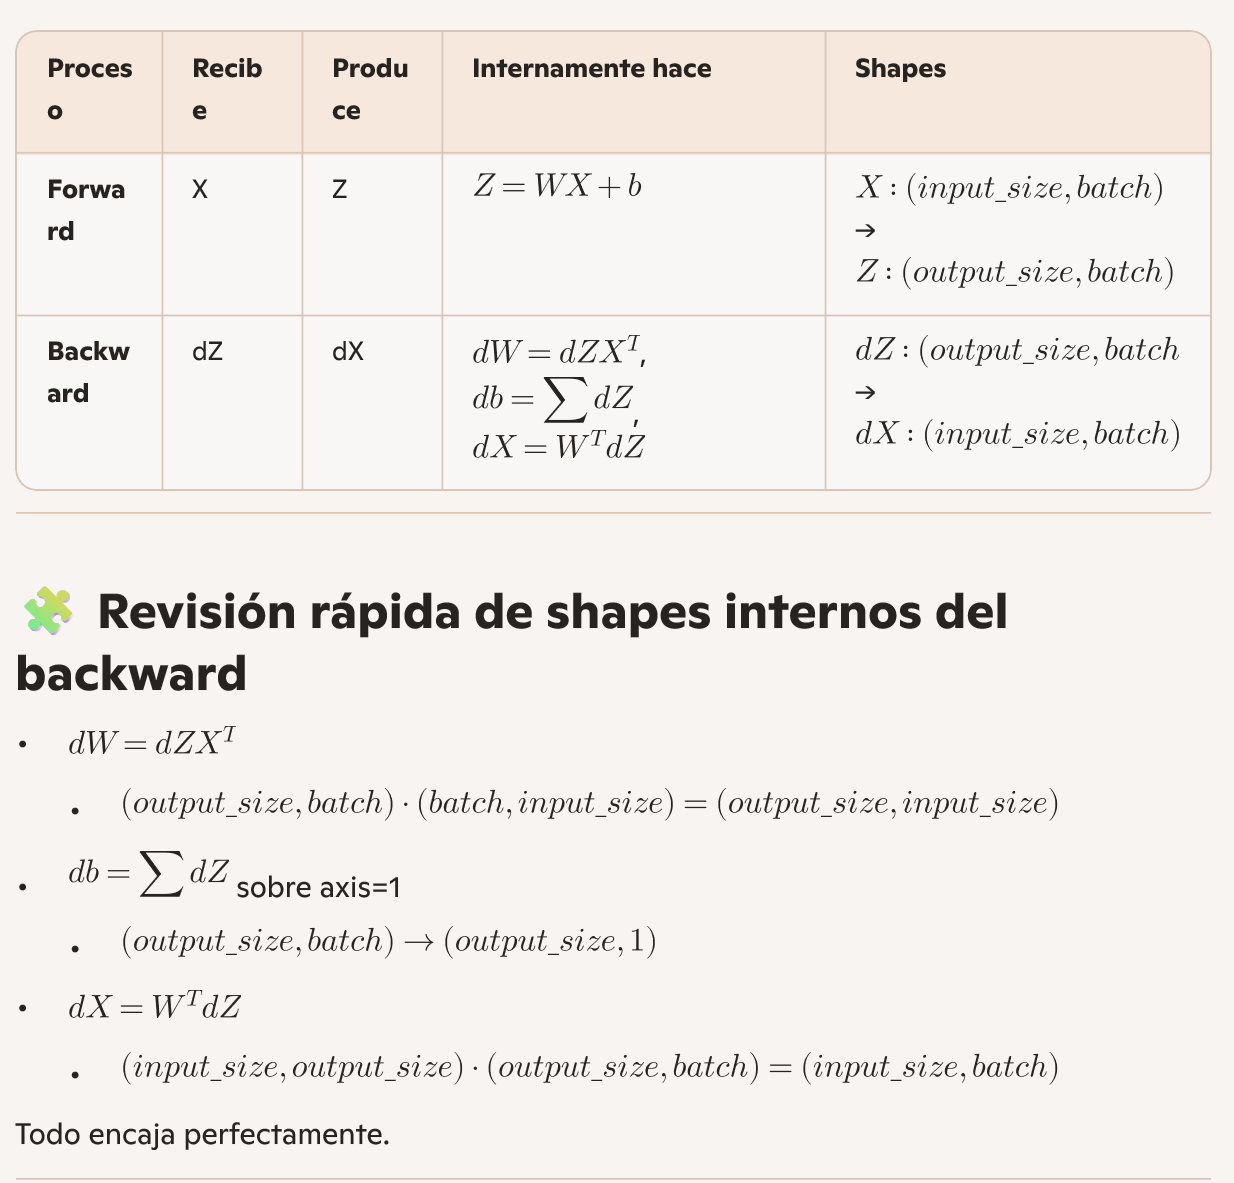

### Clase ReLU

In [68]:
class ReLU:
    def __call__(self, Z):
        self.Z = Z
        return np.maximum(0, Z)

    def backward(self, dZ):
        return dZ * (self.Z > 0)

FORWARD

Respuesta mía

Guardamos Z porque es lo que nos dice si la neurona esta activa o no, también porque se utiliza para el backward de ReLU al derivarla.


Respuesta pulida por Copilot:

Guardamos Z porque es la única forma de saber qué neuronas estaban activas en el forward, y esa información es necesaria para construir la máscara que controla el flujo del gradiente en el backward.
Y tú ya lo dijiste con tus palabras, lo cual es justo lo que buscamos en Study Mode.


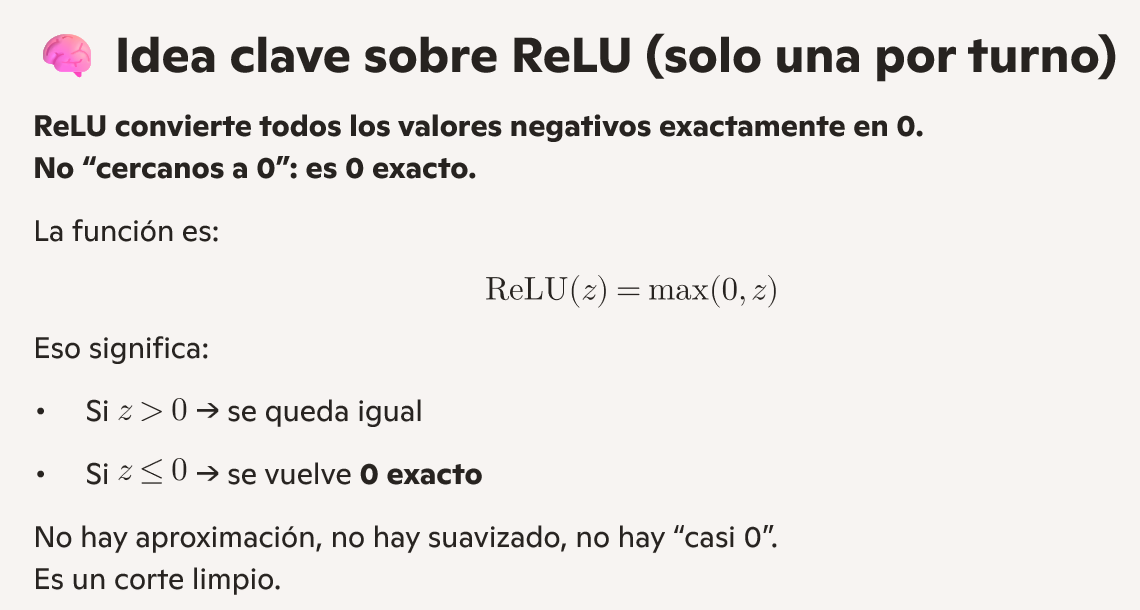



BACKWARD

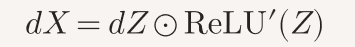

Ejercicio:

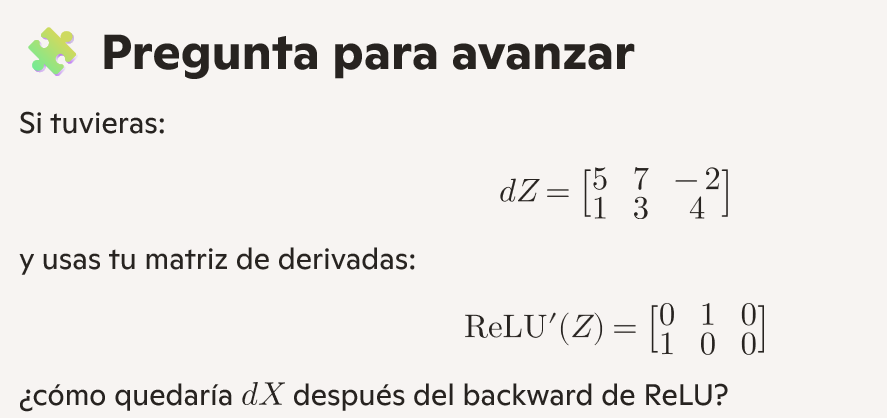

Mi duda con la clave para salir:

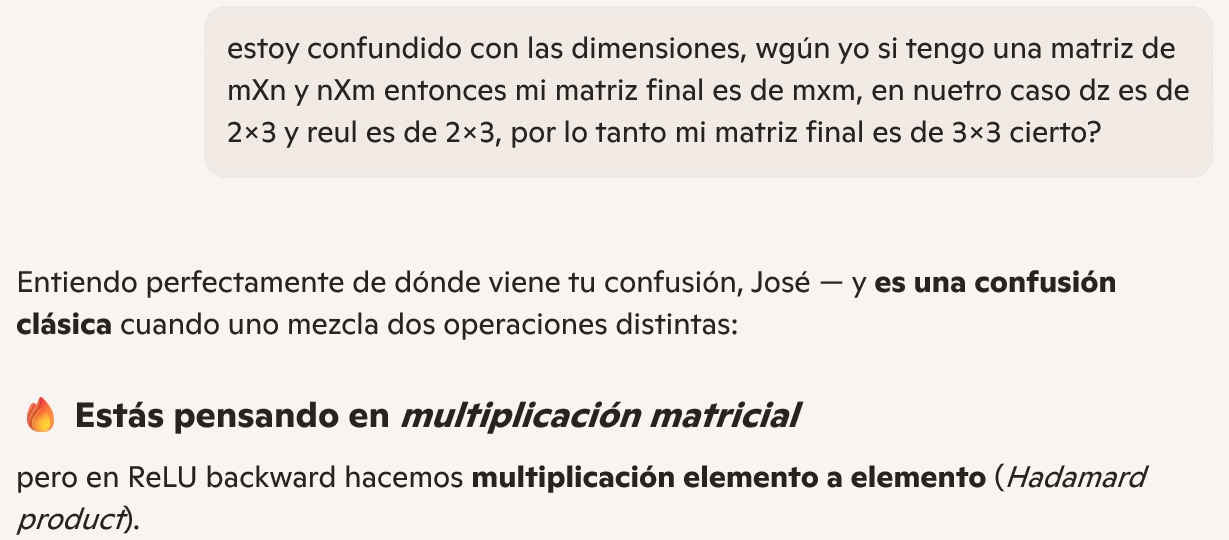

Fórmula backward de ReLU:
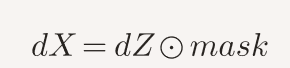

Verbalización de ReLU mía:

La máscara en ReLU sirve para que el gradiente se bloquee cuando la neurona está apagada, esto ayuda que el gradiente en dZ no se vea afectad por las apagadas.


Verbalización pulida de copilot:

La máscara de ReLU bloquea el gradiente en todas las neuronas que estaban apagadas en el forward, evitando que dZ pase por posiciones donde Z ≤ 0.


Tests Fill the GAPs:

Flujo de gradiente:

En el método backward de la clase ReLU, lo único que necesito guardar del forward es _____.

R: Z


Lógica Backward:

En el método backward de ReLU, dX se obtiene como dZ multiplicado elemento a elemento por _____.

R(JFM): mask, en el que si el elemento es <=0, entonces 0, si no, 1.


Antes del código:

En el método forward de ReLU, debo guardar Z porque _____.

R: es lo que nos dice si la neurona esta activa o no, también porque se utiliza para el backward de ReLU al derivarla.


Respuesta anterio pulida:

Guardamos Z porque es la única forma de saber qué neuronas estaban activas en el forward, y esa información es necesaria para construir la máscara que controla el flujo del gradiente en el backward.
Y tú ya lo dijiste con tus palabras, lo cual es justo lo que buscamos en Study Mode.


Utilidad de la mask:

En el backward, la línea mask = (self.Z > 0) crea una matriz donde ______.

R: todos los números positivos son 1

TIP: es una máscara booleana, es dcir, sólo tiene resultado true o false.

### Clase Sequential

1) Forward: Sequential encadena los forward de cada capa en orden.
2) Backward: Sequential recorre las capas en orden inverso y encadena los backward.

Fill the GAP:

En el forward, Sequential simplemente _____.

R: es el orden en el que se ejecutan las capas

Pulida: En el forward, Sequential ejecuta las capas en orden, pasando la salida de una como entrada de la siguiente.

En el backward, Sequential recorre las capas _____.

R: de la última a la primera.

Pulida: Sequential recorre las capas en orden inverso, empezando por la última y terminando en la primera, pasando el gradiente de una capa a la anterior.

NOTA: Es la regla de oro en el backward.

In [69]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, X):
        out = X
        for layer in self.layers:
            out = layer(out)
        return out

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def update(self, lr):
        for layer in self.layers:
            if hasattr(layer, "update"):
                layer.update(lr)

## Fill in the GAPS:


1. ¿Qué representa dX?

Contexto: dX es el gradiente respecto a la entrada de la capa Linear.

Frase: “Entonces, dX representa cómo cambiaría la pérdida si yo cambiara…”

Tu respuesta: “la entrada”

Corrección: “dX representa cómo cambiaría la pérdida si cambiara la entrada X, porque mide la sensibilidad de la pérdida respecto a X.”

2. ¿Cómo se obtiene db?

Contexto: El bias se suma igual para todos los ejemplos del batch.

Frase: “Entonces, db se obtiene…”

Tu respuesta: “es la suma de las pérdidas al cambiar la entrada”

Corrección: “db se obtiene sumando dZ sobre el batch, porque el bias afecta por igual a todos los ejemplos.”

3. ¿Por qué db no depende de X?

Contexto: El bias no interactúa con X, solo se suma a Z.

Frase: “Entonces, db no depende de X 

Tu respuesta: “porque sólo indica el ajuste que hay que hacer…”

Corrección: “db no depende de X porque el bias se suma directamente a Z y no interactúa con la entrada.”

4. ¿Qué gradiente devuelve Linear?

Contexto: Solo un gradiente viaja hacia la capa anterior.

Frase: “Entonces, en el backward de Linear, debo devolver…”

Tu respuesta: “dX, que es lo que produce”
Corrección: “El backward de Linear devuelve dX, porque es el gradiente que necesita la capa anterior.”

5. ¿Qué usa el método update?

Contexto: Solo se actualizan parámetros entrenables.
Frase: “Entonces, en el método update, debo usar…”

Tu respuesta: “los parámetros entrenables”
Corrección: “El método update usa dW y db para actualizar W y b.”

6. ¿Qué pasa con ReLU en update?

Contexto: ReLU no tiene parámetros entrenables.
Frase: “Entonces, en una capa como ReLU, el método update…”

Tu respuesta: “no aplica porque no hay parámetros entrenables”

Corrección: “Correcto: ReLU no tiene parámetros, así que update no hace nada.”

7. ¿Qué necesita ReLU para el backward?

Contexto: ReLU solo filtra gradientes.
Frase: “Entonces, en el backward de ReLU, lo único que debo hacer es…”

Tu respuesta: “guardar X y las Z>0 para calcular los gradientes”

Corrección: “Solo necesitas guardar la máscara X>0; no hace falta guardar X completo.”

8. ¿Qué devuelve ReLU en el backward?

Contexto: ReLU no aprende, solo filtra.

Frase: “Entonces, el backward de ReLU devuelve…”
Tu respuesta: “dX de las neuronas con X>0”

Corrección: “Exacto: devuelve dX filtrado por la máscara X>0.”

9. ¿Por qué ReLU no tiene dW ni db?

Contexto: ReLU no tiene parámetros.
Frase: “Entonces, la razón por la que ReLU no necesita dW ni db es porque…”

Tu respuesta: “resulta innecesario calcular dW y db…”

Corrección: “ReLU no necesita dW ni db porque no tiene parámetros entrenables.”

10. Diferencia entre Linear y ReLU en backward

Contexto: Linear aprende; ReLU solo filtra.
Frase: “Entonces, la diferencia fundamental entre Linear y ReLU en el backward es que Linear…”

Tu respuesta: “requiere actualizar los pesos…”

Corrección: “Linear aprende ajustando W y b; ReLU solo filtra gradientes sin actualizar nada.”

11. Flujo del backward en una red secuencial

Contexto: El gradiente viaja en orden inverso.

Frase: “Entonces, en una red secuencial, el flujo del backward va…”

Tu respuesta: “la última capa a la inicial”
Corrección: “Correcto: el backward va desde la última capa hacia la primera.”




### Cost Function

In [71]:
class SoftmaxCrossEntropy:
    def __init__(self):
        self.probs = None
        self.y_true = None
        self.N = None

    def softmax(self, logits):
        z = logits - np.max(logits, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, logits, y_true):
        # logits: (batch, classes)
        self.N = logits.shape[0]
        self.y_true = y_true
        self.probs = self.softmax(logits)

        correct_logprobs = -np.log(self.probs[np.arange(self.N), y_true] + 1e-12)
        return np.mean(correct_logprobs), self.probs

    def backward(self):
        dlogits = self.probs.copy()
        dlogits[np.arange(self.N), self.y_true] -= 1
        return dlogits / self.N

### Loop de entrenamiento

### Create your model and train it

In [72]:
def accuracy(model, X, Y, mb_size):
    correct = 0
    total = 0

    for X_mb, Y_mb in get_minibatches(X, Y, batch_size=mb_size):
        logits = model(X_mb.T)              # (classes, batch)
        preds = np.argmax(logits, axis=0)
        correct += np.sum(preds == Y_mb)
        total += len(Y_mb)

    return correct / total

In [73]:
def train(model, x_train, y_train, x_val, y_val, epochs, mb_size=128, learning_rate=1e-3):
    criterion = SoftmaxCrossEntropy()

    for epoch in range(epochs):
        for X_mb, Y_mb in get_minibatches(x_train, y_train, batch_size=mb_size):

            # Forward del modelo
            logits = model(X_mb.T)              # (classes, batch)

            # Loss necesita (batch, classes)
            loss, _ = criterion.forward(logits.T, Y_mb)

            # Backward de la loss
            dlogits = criterion.backward()      # (batch, classes)

            # Backward del modelo
            model.backward(dlogits.T)           # (classes, batch)

            # Update
            model.update(learning_rate)

        val_acc = accuracy(model, x_val, y_val, mb_size)
        print(f"Epoch {epoch+1}/{epochs}  loss: {loss:.4f}  val_acc: {val_acc:.4f}")

In [77]:
model = Sequential([
    linear(784, 200),
    ReLU(),
    linear(200, 200),
    ReLU(),
    linear(200, 24)   # ← CORREGIDO
])


In [83]:
train(
    model,
    x_train, y_train,
    x_val, y_val,
    epochs=50,
    mb_size=512,
    learning_rate=1e-1
)

Epoch 1/50  loss: 0.0008  val_acc: 0.7934
Epoch 2/50  loss: 0.0008  val_acc: 0.7936
Epoch 3/50  loss: 0.0007  val_acc: 0.7936
Epoch 4/50  loss: 0.0007  val_acc: 0.7942
Epoch 5/50  loss: 0.0007  val_acc: 0.7942
Epoch 6/50  loss: 0.0007  val_acc: 0.7945
Epoch 7/50  loss: 0.0007  val_acc: 0.7945
Epoch 8/50  loss: 0.0007  val_acc: 0.7945
Epoch 9/50  loss: 0.0007  val_acc: 0.7942
Epoch 10/50  loss: 0.0007  val_acc: 0.7942
Epoch 11/50  loss: 0.0007  val_acc: 0.7942
Epoch 12/50  loss: 0.0007  val_acc: 0.7942
Epoch 13/50  loss: 0.0007  val_acc: 0.7942
Epoch 14/50  loss: 0.0007  val_acc: 0.7942
Epoch 15/50  loss: 0.0006  val_acc: 0.7942
Epoch 16/50  loss: 0.0006  val_acc: 0.7942
Epoch 17/50  loss: 0.0006  val_acc: 0.7945
Epoch 18/50  loss: 0.0006  val_acc: 0.7945
Epoch 19/50  loss: 0.0006  val_acc: 0.7945
Epoch 20/50  loss: 0.0006  val_acc: 0.7945
Epoch 21/50  loss: 0.0006  val_acc: 0.7950
Epoch 22/50  loss: 0.0006  val_acc: 0.7950
Epoch 23/50  loss: 0.0006  val_acc: 0.7950
Epoch 24/50  loss: 0

### Test your model on Random data from your test set

In [84]:
def plot_number(img):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

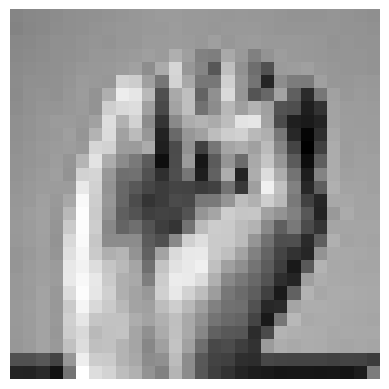

el valor predicho es: s el valor real es:e


In [113]:
idx = np.random.randint(len(y_test))
plot_number(x_test[idx].reshape(28,28))
#pred = model.predict(x_test[idx].reshape(-1, 1))
#sugenrecia de copilot
logits = model(x_test[idx].reshape(-1, 1))
pred = np.argmax(logits, axis=0)[0]
print(f'el valor predicho es: {alphabet[pred]} el valor real es:{alphabet[y_test[idx]]}')